# Load Data

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\maxan\OneDrive\Desktop\0. Personal Projects\market-intelligence-pipeline")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd
import numpy as np
import duckdb

from src.config import (
    DATABASE_PATH,
    ROLLING_WINDOWS,
    LAGGED_WINDOWS,
    MA_WINDOWS,
    TICKERS,
    START_DATE,
    END_DATE
)

from src.features import (
    build_price_feature_columns
)

CALENDAR = "no_calendar"


def pull_calendar_table(table_name: str, calendar: str) -> pd.DataFrame:

    print("[START] Connecting to database...")

    con = duckdb.connect(DATABASE_PATH)

    print(f"[START] Reading {table_name}")

    df = con.sql(f"""
    
        SELECT *
        FROM {table_name}

    """).df()

    print(f"[DONE] Read {table_name}")

    con.close()

    print(f"[START] Building {CALENDAR} required columns...")

    base_cols = [
        "ticker",
        "date",
        "open",
        "high",
        "low",
        "close",
        "adj_close",
        "volume"
    ]

    feature_columns = build_price_feature_columns(
        calendars = [CALENDAR],
        rolling_windows = ROLLING_WINDOWS,
        lagged_windows = LAGGED_WINDOWS,
        ma_windows = MA_WINDOWS
    )

    expected_columns = base_cols + list(feature_columns.keys())

    calendar_df = df[expected_columns].copy()

    print(f"[DONE] Filtered to {CALENDAR}")

    calendar_df["date"] = pd.to_datetime(calendar_df["date"])

    calendar_df = calendar_df.sort_values(["ticker", "date"])

    print(f"[DONE] Prepared and sorted table")

    return calendar_df

In [3]:
df = pull_calendar_table(
    table_name = "price_features", 
    calendar = CALENDAR
    )

print(f"[STEP] Loaded price_features table selecting {CALENDAR} columns")
print(df.head(10))
print(df.columns)

[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...
[DONE] Filtered to no_calendar
[DONE] Prepared and sorted table
[STEP] Loaded price_features table selecting no_calendar columns
      ticker       date        open        high         low       close  \
0        GLD 2018-01-02  124.660004  125.180000  124.389999  125.150002   
1        GLD 2018-01-03  125.050003  125.089996  124.099998  124.820000   
8585     GLD 2018-01-04  124.889999  125.849998  124.739998  125.459999   
4299     GLD 2018-01-05  124.930000  125.480003  124.830002  125.330002   
2        GLD 2018-01-08  125.199997  125.320000  124.900002  125.309998   
7160     GLD 2018-01-09  124.489998  124.860001  124.230003  124.730003   
4300     GLD 2018-01-10  125.169998  125.309998  124.720001  125.029999   
10109    GLD 2018-01-11  125.370003  125.660004  125.250000  125.440002   
10110    GLD 2018-01-12  126.010002  127.129997  125.80

In [4]:
table_count = 0
graph_count = 0

# Plot Adj_Close

Graph 8


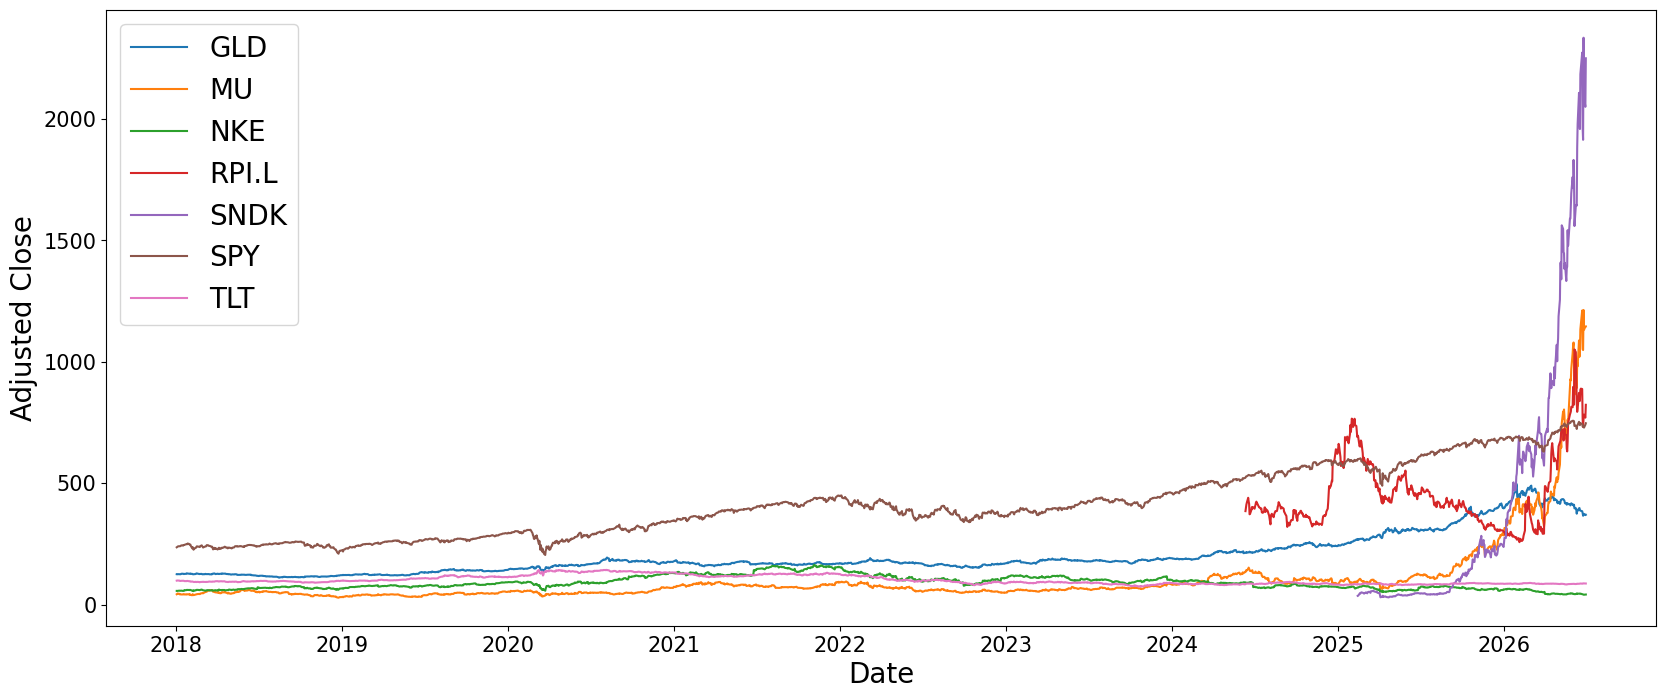

In [14]:
import matplotlib.pyplot as plt

date = "date"
price = "adj_close"
ticker = "ticker"

df_1 = df.copy()

plt.figure(figsize = (20,8))

for ticker, group in df_1.groupby(ticker):

    plt.plot(group[date], group[price], label = ticker)

plt.legend(fontsize=20)
plt.xlabel("Date", fontsize=20)
plt.ylabel("Adjusted Close", fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

graph_count += 1
print(f"Graph {graph_count}")

plt.show()


# Compare Normalised Prices

Graph 12


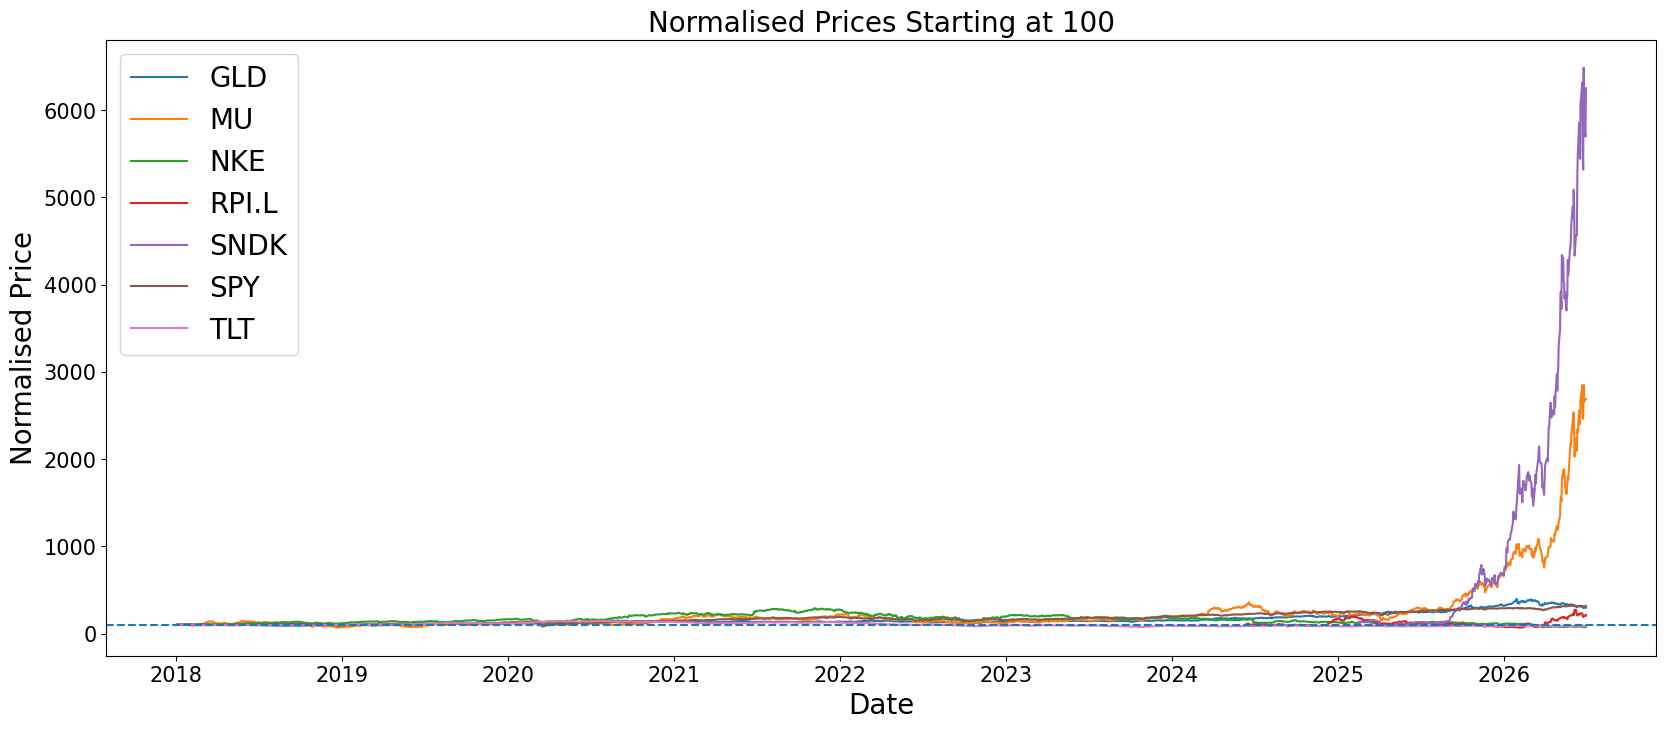

In [21]:
import matplotlib.pyplot as plt

df_2 = df.copy()

ticker = "ticker"
date = "date"
price = "adj_close"
normalised_price = "normalised_close"

df_2[normalised_price] = df_2.groupby(ticker)[price].transform(
    lambda x: x / x.iloc[0] * 100
)

plt.figure(figsize = (20,8))

for asset, group in df_2.groupby(ticker):

    plt.plot(group[date], group[normalised_price], label = asset)

plt.axhline(100, linestyle = "--")
plt.legend(fontsize=20)
plt.title(f"Normalised Prices Starting at 100", fontsize = 20)
plt.xlabel("Date", fontsize = 20)
plt.ylabel("Normalised Price", fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

graph_count += 1
print(f"Graph {graph_count}")

plt.show()
    

Graph 15


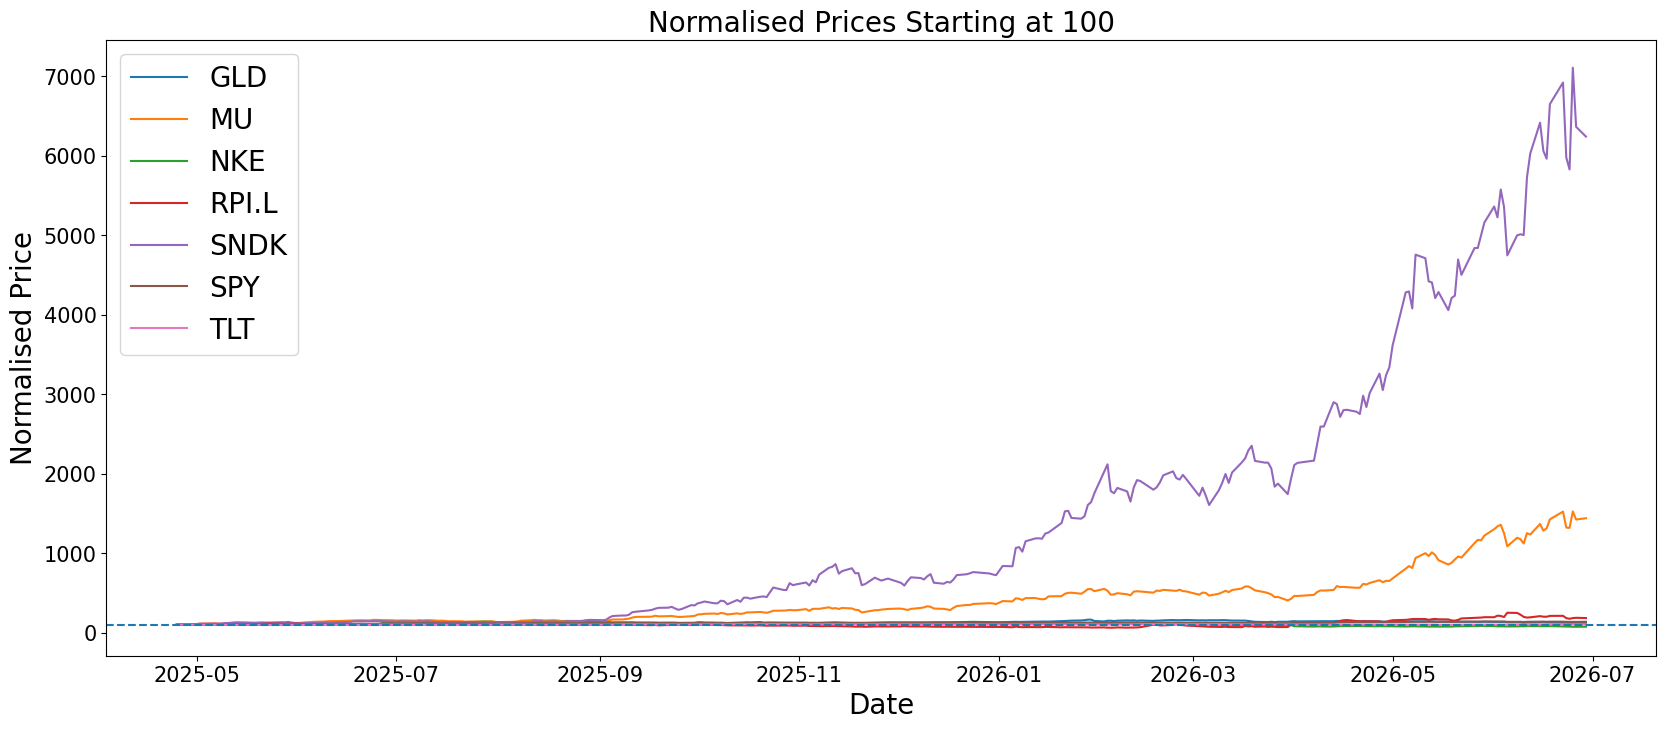

In [ ]:
shared_df = df_2.dropna(axis = 0, how = "any").copy()

n_tickers = shared_df[ticker].nunique()

common_dates = (
    shared_df.groupby(date)[ticker]
        .nunique()
        .loc[lambda x: x == n_tickers]
        .index
)

shared_df = shared_df[shared_df[date].isin(common_dates)]

shared_df = shared_df.sort_values([ticker, date])

shared_df[normalised_price] = shared_df.groupby(ticker)[price].transform(
    lambda x: x / x.iloc[0] * 100
)

plt.figure(figsize = (20,8))

for asset, group in shared_df.groupby(ticker):

    plt.plot(group[date], group[normalised_price], label = asset)

plt.axhline(100, linestyle = "--")
plt.legend(fontsize=20)
plt.title(f"Normalised Prices Starting at 100", fontsize = 20)
plt.xlabel("Date", fontsize = 20)
plt.ylabel("Normalised Price", fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

graph_count += 1
print(f"Graph {graph_count}")

plt.show()

Graph 16


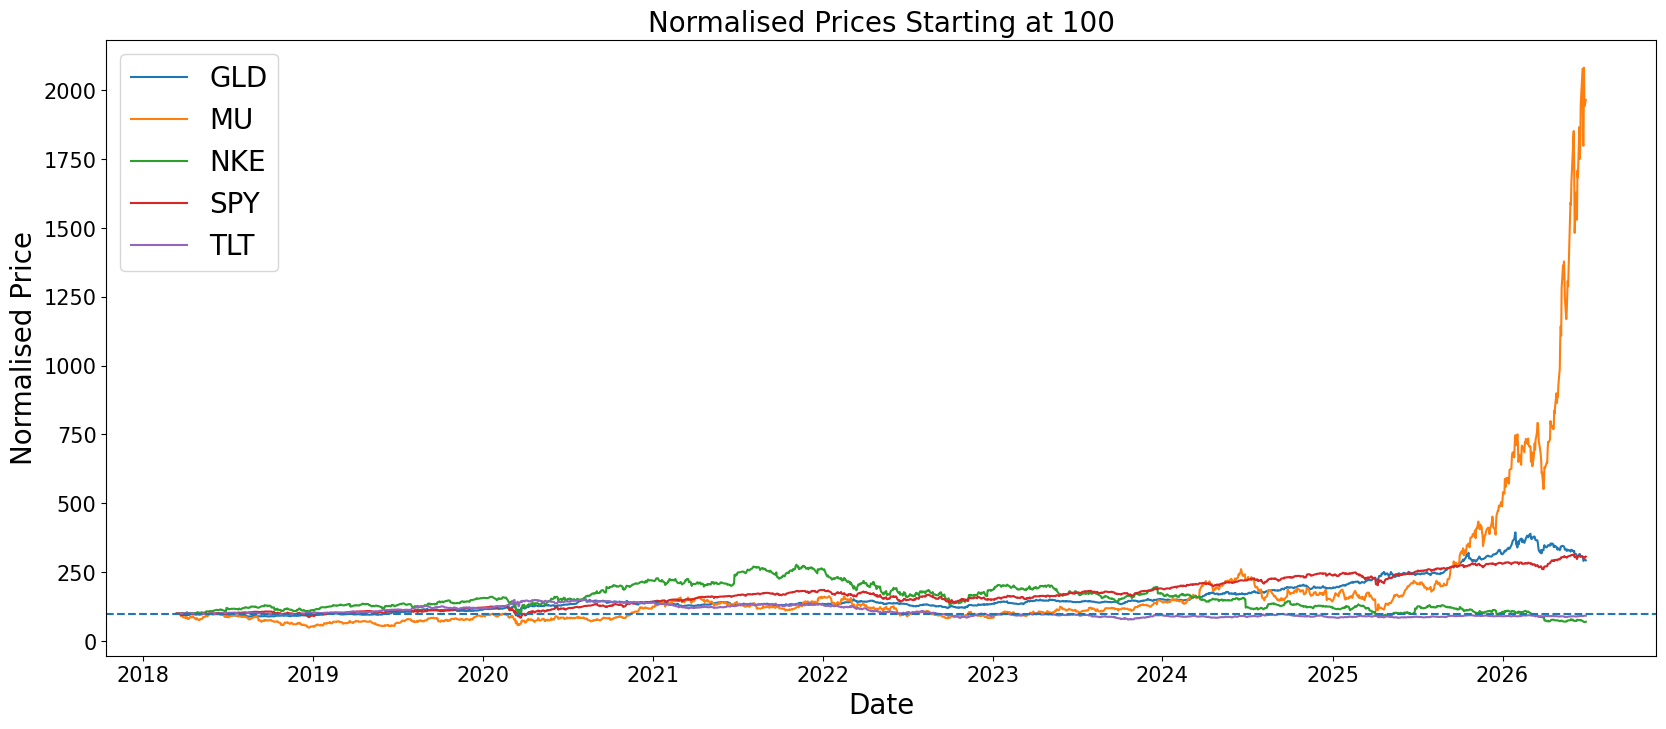

In [26]:
remove_tickers = ["SNDK", "RPI.L"]  # replace with tickers you want to remove

reduced_df = (
    df_2.loc[~df_2[ticker].isin(remove_tickers)]
        .dropna(axis=0, how="any")
        .copy()
)

reduced_df = reduced_df.sort_values([ticker, date])

reduced_df[normalised_price] = reduced_df.groupby(ticker)[price].transform(
    lambda x: x / x.iloc[0] * 100
)

plt.figure(figsize = (20,8))

for asset, group in reduced_df.groupby(ticker):

    plt.plot(group[date], group[normalised_price], label = asset)

plt.axhline(100, linestyle = "--")
plt.legend(fontsize=20)
plt.title(f"Normalised Prices Starting at 100", fontsize = 20)
plt.xlabel("Date", fontsize = 20)
plt.ylabel("Normalised Price", fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

graph_count += 1
print(f"Graph {graph_count}")

plt.show()

# Major Price Movements

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML

df_3 = df.copy()

date = "date"
ticker = "ticker"
log_return = f"log_return_{CALENDAR}"
daily_return = f"daily_return_{CALENDAR}"
drawdown = f"drawdown_{CALENDAR}"

daily_summary = (
    df.groupby(ticker)[daily_return]
        .agg(
            max_daily_gain = "max",
            min_daily_loss = "min"
        )
)

weekly_returns = (
    df_3.set_index(date)
        .groupby(ticker)[log_return]
        # Need to ensure the date is in pd.Datetime format,
        # it accounts for weekends by itself grouping by every 
        # 7 days rather than every 7 rows.
        .resample("W")
        .sum()
)

weekly_summary = (
    weekly_returns.groupby(ticker)
        .agg(
            max_weekly_gain = "max",
            min_weekly_gain = "min"
        )
)

weekly_summary["max_weekly_gain"] = np.exp(weekly_summary["max_weekly_gain"]) - 1
weekly_summary["min_weekly_gain"] = np.exp(weekly_summary["min_weekly_gain"]) - 1

summary = daily_summary.join(weekly_summary)

html_parts = []

for column in summary.columns:
    table = summary[[column]].sort_values(column).reset_index().style.hide(axis="index")

    html_parts.append(f"""
    <div>
        <h3> {column} - Sorted </h3>
        {table.to_html()}
    </div>
    """)

html = f"""
<div style="display: flex; gap: 30px; align-items: flex-start;">
    {''.join(html_parts)}
</div>
"""

display(HTML(html))

ticker,max_daily_gain
GLD,0.063587
TLT,0.075196
SPY,0.105019
NKE,0.155314
MU,0.192916
SNDK,0.286494
RPI.L,0.470910
ticker,min_daily_loss
SNDK,-0.213016
NKE,-0.199809


# Unusual Behaviour